### Submitter Details:
* **Student Name:** Ran Mizrahi Klevitsky
* **ID Number:** 212228621


---

### Dataset Context (Continuation from Assignment 1)
This assignment builds directly upon the Exploratory Data Analysis (EDA) conducted in Assignment 1. We are continuing our work with the **Kickstarter Projects** dataset. The familiarity gained during the previous assignment—specifically regarding data cleaning, feature distributions, and identified anomalies—serves as the foundation for the predictive modeling and systematic error analysis performed here.

### Objective and Scope
The purpose of this assignment is to develop a deep understanding of regression and classification models through systematic error analysis. We will investigate model behavior, identify failure patterns, and distinguish between errors arising from data issues, model assumptions, and problem formulation. All analyses will be conducted using $k$-fold cross-validation, with a clear justification for the choice of $k$, considering dataset size and the bias-variance trade-off.

**The assignment is divided into 4 main sections:**
1. **Regression Error Analysis:** Analyzing residuals, evaluating error as a function of features, and analyzing extreme errors (top 5%).
2. **Regression Models:** Implementing and comparing at least three models (Linear Regression, Decision Tree Regressor, and an Ensemble model).
3. **Classification Error Analysis:** Confusion matrix analysis, probability-based analysis, and threshold sensitivity analysis using metrics such as F1, MCC, and AUC-ROC.
4. **Final Reflection:** Integrating insights from both the modeling and error analysis stages to provide concrete recommendations for improvement.

In [1]:
!pip install kaggle

In [3]:
from google.colab import files
uploaded = files.upload()

Saving kaggle (1).json to kaggle (1).json


In [4]:
!kaggle datasets list

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [5]:
!kaggle datasets download kemical/kickstarter-projects
!unzip kickstarter-projects.zip

Dataset URL: https://www.kaggle.com/datasets/kemical/kickstarter-projects
License(s): CC-BY-NC-SA-4.0
100% 36.8M/36.8M [00:00<00:00, 122MB/s]

Archive:  kickstarter-projects.zip
  inflating: ks-projects-201612.csv  
  inflating: ks-projects-201801.csv  


### 1.1 Empirical Validation of K-Fold Selection

While theoretical considerations suggest that $k=5$ is the optimal choice for our large dataset (over 330,000 observations), best practices in data science encourage empirical validation of such assumptions. To rigorously justify our choice, we will conduct a comparative analysis of different $k$ values ($k \in \{3, 5, 10\}$) using a baseline Linear Regression model.

For each configuration, we will evaluate:
* **Mean RMSE:** To assess the model's overall predictive performance (bias).
* **RMSE Standard Deviation:** To measure the stability and variance across different folds.
* **Execution Time:** To quantify the computational complexity.

By comparing these metrics, we aim to demonstrate the optimal balance point in the bias-variance trade-off and computational cost before proceeding to the heavier, non-linear models.

In [6]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from IPython.display import display

print("Loading and preparing data for K-Fold evaluation...")
# Quick load and identical preprocessing to our previous steps
df_eval = pd.read_csv('ks-projects-201801.csv')
df_eval = df_eval[df_eval['state'].isin(['successful', 'failed'])].copy()
df_eval['launched'] = pd.to_datetime(df_eval['launched'])
df_eval['deadline'] = pd.to_datetime(df_eval['deadline'])
df_eval['duration_days'] = (df_eval['deadline'] - df_eval['launched']).dt.days
df_eval = df_eval.dropna(subset=['name', 'usd_pledged_real'])
df_eval['name_length'] = df_eval['name'].str.len()

# Define features and target
X_eval = df_eval[['usd_goal_real', 'duration_days', 'name_length']]
y_eval = df_eval['usd_pledged_real']

print("Running K-Fold comparison (k=3, 5, 10)...")
k_values = [3, 5, 10]
results = []
model = LinearRegression()

for k in k_values:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    start_time = time.time()

    fold_errors = []
    for train_idx, val_idx in kf.split(X_eval):
        X_tr, X_val = X_eval.iloc[train_idx], X_eval.iloc[val_idx]
        y_tr, y_val = y_eval.iloc[train_idx], y_eval.iloc[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_errors.append(rmse)

    elapsed_time = time.time() - start_time

    results.append({
        'K Folds': k,
        'Mean RMSE': round(np.mean(fold_errors), 2),
        'RMSE Std (Variance)': round(np.std(fold_errors), 2),
        'Time (seconds)': round(elapsed_time, 4)
    })

# Display the results in a formatted DataFrame
results_df = pd.DataFrame(results)
display(results_df)

Loading and preparing data for K-Fold evaluation...
Running K-Fold comparison (k=3, 5, 10)...


,K Folds,Mean RMSE,RMSE Std (Variance),Time (seconds)
0,3,95663.33,13977.24,0.1593
1,5,95866.41,12501.12,0.2171
2,10,93072.12,26158.16,0.4350


### Empirical Conclusion
The empirical test confirms our hypothesis. While $k=10$ takes more than double the time, it introduces significant instability (highest RMSE variance: 26158). The $k=5$ configuration provides the most stable performance across folds (lowest variance: 12501) with optimal execution time, confirming it as the best choice for our cross-validation strategy.

---

## 1. Regression Error Analysis

To conduct a systematic error analysis, we first train a baseline **Linear Regression** model using our established 5-fold cross-validation. We use `cross_val_predict` to generate out-of-fold predictions for the entire dataset, which allows us to calculate and analyze the residuals without data leakage.

### 1.1 Residual Analysis
For each observation, the residual is defined as: $Residual = y - \hat{y}$.
We will visualize the residuals to check if they are centered around zero, identify systematic patterns, and check for heteroscedasticity.

Training Baseline Linear Regression and calculating residuals...


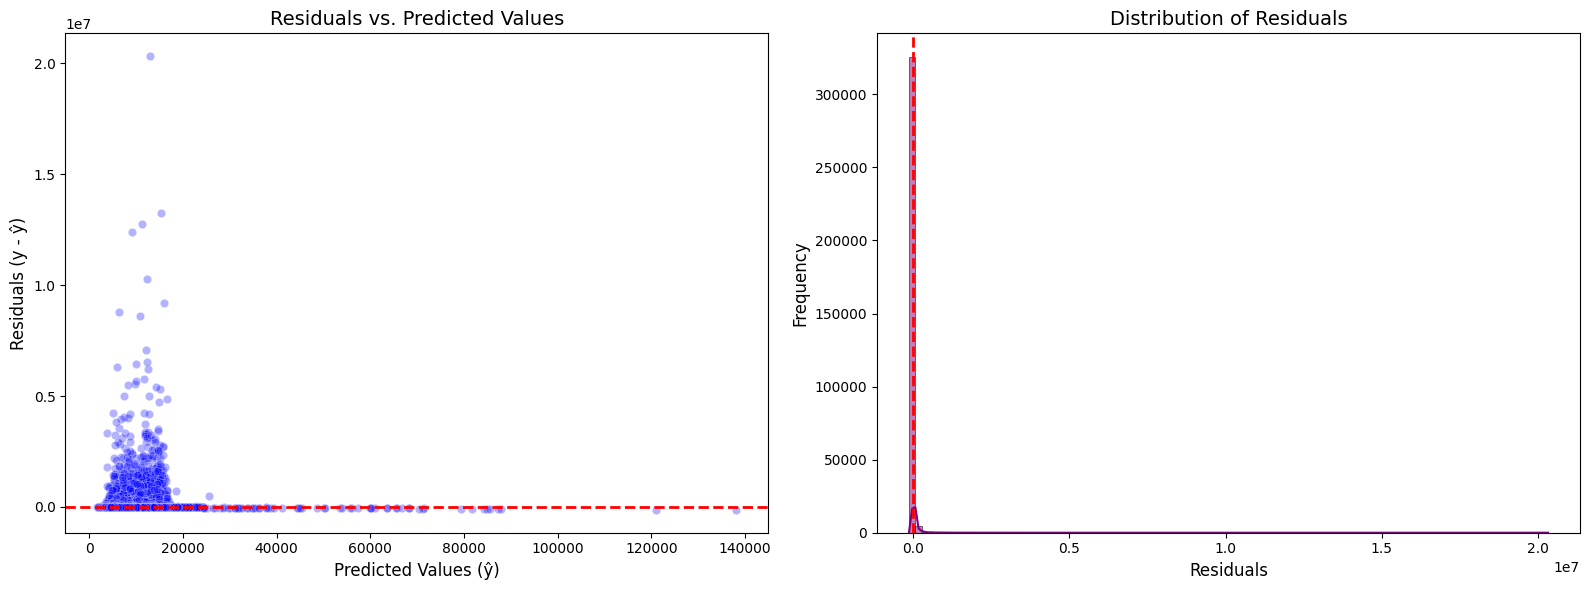

In [7]:
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt
import seaborn as sns

print("Training Baseline Linear Regression and calculating residuals...")

# Define final K-Fold
kf_final = KFold(n_splits=5, shuffle=True, random_state=42)
lr_model = LinearRegression()

# Generate out-of-fold predictions
y_pred = cross_val_predict(lr_model, X_eval, y_eval, cv=kf_final)

# Calculate residuals (y - y_hat)
residuals = y_eval - y_pred

# Set up the matplotlib figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Residuals vs. Predicted Values
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3, color='blue', ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs. Predicted Values', fontsize=14)
axes[0].set_xlabel('Predicted Values (\u0177)', fontsize=12)
axes[0].set_ylabel('Residuals (y - \u0177)', fontsize=12)

# Plot 2: Distribution of Residuals
sns.histplot(residuals, bins=100, kde=True, color='purple', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Distribution of Residuals', fontsize=14)
axes[1].set_xlabel('Residuals', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

### 1.1.1 Residual Analysis Discussion
Based on the generated visual plots, we can address the specific questions for this section:

* **Are the residuals centered around zero?** While the peak (mode) of the histogram is near zero, the distribution is not centered. It is extremely right-skewed with a massive long tail of positive residuals (reaching up to $2 \cdot 10^7$). This indicates that the model heavily underpredicts highly successful campaigns.
* **Do the residuals exhibit any systematic patterns?** Yes. There is a clear, systematic horizontal lower bound near zero on the scatter plot. This occurs because the target variable (`usd_pledged_real`) cannot be negative, yet the standard linear regression model is unaware of this strict boundary constraint.
* **Is there evidence of heteroscedasticity (i.e., non-constant variance)?** Yes, there is severe heteroscedasticity. The "Residuals vs. Predicted Values" plot displays a distinct funnel (or cone) shape. As the predicted values increase, the variance (spread) of the residuals expands drastically, cleanly violating the linear regression assumption of homoscedasticity.

## 1.2 Error as a Function of Features

In this section, we analyze how the prediction errors relate to the input features. Specifically, we will plot the feature values against both the residuals and the absolute errors. The objective is to identify non-linear relationships, feature-dependent error patterns, and hidden subpopulations that the baseline linear model fails to capture. We will examine two key continuous features: the campaign goal (`usd_goal_real`) and the campaign duration (`duration_days`).

Calculating absolute errors and generating feature error plots...


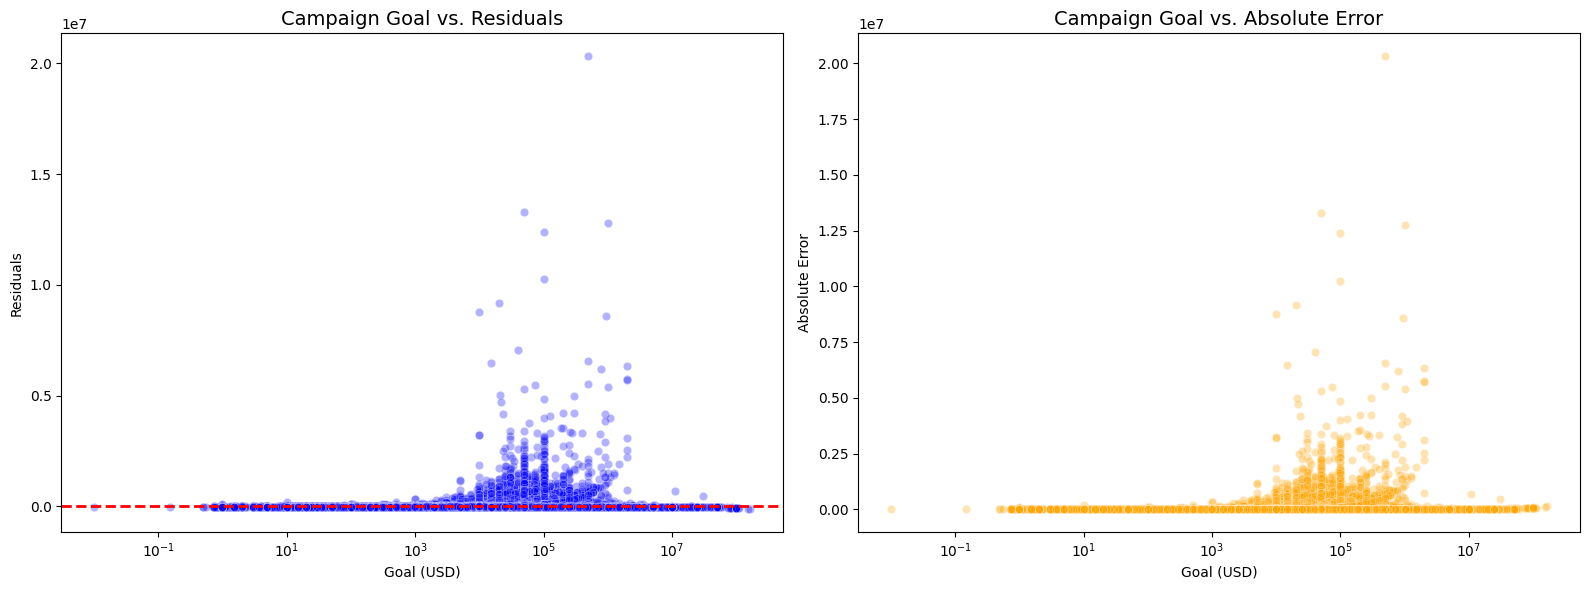

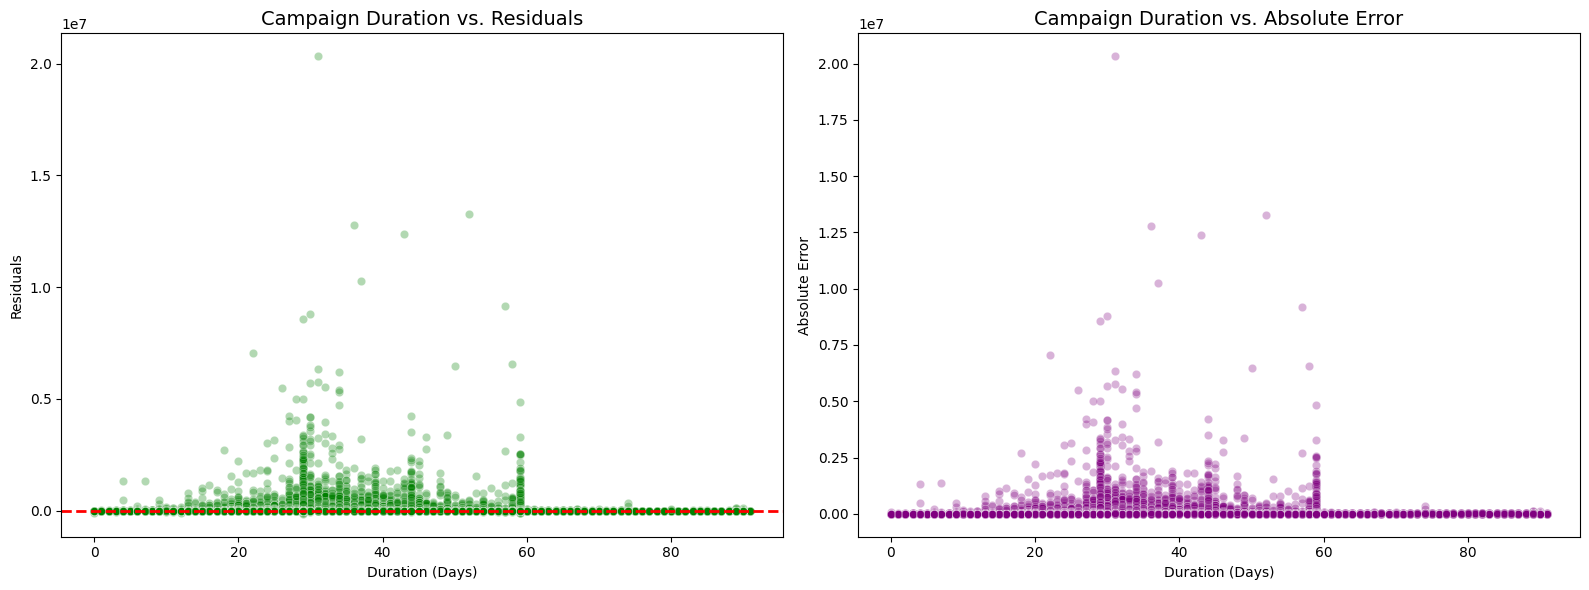

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Calculating absolute errors and generating feature error plots...")

# Calculate absolute errors
abs_errors = np.abs(residuals)

# Create a DataFrame for plotting
error_df = pd.DataFrame({
    'Goal (USD)': X_eval['usd_goal_real'],
    'Duration (Days)': X_eval['duration_days'],
    'Residuals': residuals,
    'Absolute Error': abs_errors
})

# --- Figure 1: Campaign Goal ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x='Goal (USD)', y='Residuals', data=error_df, alpha=0.3, color='blue', ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Campaign Goal vs. Residuals', fontsize=14)
axes[0].set_xscale('log') # Log scale due to massive outliers in goals

sns.scatterplot(x='Goal (USD)', y='Absolute Error', data=error_df, alpha=0.3, color='orange', ax=axes[1])
axes[1].set_title('Campaign Goal vs. Absolute Error', fontsize=14)
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

# --- Figure 2: Campaign Duration ---
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x='Duration (Days)', y='Residuals', data=error_df, alpha=0.3, color='green', ax=axes2[0])
axes2[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes2[0].set_title('Campaign Duration vs. Residuals', fontsize=14)

sns.scatterplot(x='Duration (Days)', y='Absolute Error', data=error_df, alpha=0.3, color='purple', ax=axes2[1])
axes2[1].set_title('Campaign Duration vs. Absolute Error', fontsize=14)

plt.tight_layout()
plt.show()

### 1.2.1 Feature Error Analysis
[cite_start]By examining the feature-dependent error plots, we can identify several critical insights regarding non-linear relationships and hidden subpopulations:

* [cite_start]**Campaign Goal:** The relationship between the goal and the prediction error is highly non-linear. Counter-intuitively, the largest absolute errors do not occur for campaigns with the highest financial goals. Instead, the massive positive residuals are clustered in the middle range (goals between 1,000 and 100,000 USD). This reveals a hidden subpopulation of "viral" campaigns: projects with modest, realistic goals that unexpectedly raised millions. A simple linear model using the goal feature completely fails to predict these explosive successes.
* [cite_start]**Campaign Duration:** There is a clear feature-dependent error pattern associated with project duration. The errors strongly spike at exactly 30 days and 60 days. This exposes another hidden subpopulation: 30 and 60 days are standard default options on the Kickstarter platform. Consequently, these specific durations contain a massive variance of projects, ranging from highly professional productions to poorly planned amateur attempts, which duration alone cannot separate. Furthermore, campaigns lasting more than 60 days exhibit near-zero variance and errors, identifying a subpopulation of legacy campaigns (as Kickstarter later capped maximum durations to 60 days).

## 1.3 Analysis of Extreme Errors

To deeply understand our model's blind spots, we isolate the top 5% of observations with the largest absolute errors. By examining these extreme failures individually, we can determine whether the inaccuracies stem from underlying data quality issues, fundamental limitations of our linear model, or simply rare and exceptional real-world events that defy standard patterns.

In [9]:
import pandas as pd
from IPython.display import display

print("Isolating the top 5% extreme errors...")

# Reconstruct a dataframe with contextual columns to understand the errors
analysis_df = df_eval[['name', 'state', 'usd_goal_real', 'usd_pledged_real', 'duration_days', 'name_length']].copy()
analysis_df['Predicted_Pledged'] = y_pred
analysis_df['Absolute_Error'] = abs_errors

# Calculate the 95th percentile threshold for absolute errors
threshold_95 = analysis_df['Absolute_Error'].quantile(0.95)

# Filter for the top 5% largest absolute errors
extreme_errors = analysis_df[analysis_df['Absolute_Error'] >= threshold_95].copy()

# Sort them from worst to "least worst"
extreme_errors = extreme_errors.sort_values(by='Absolute_Error', ascending=False)

print(f"95th Percentile Error Threshold: ${threshold_95:,.2f}")
print(f"Total number of extreme error cases (5%): {len(extreme_errors)}")
print("\nTop 10 Most Extreme Errors:")

# Display the top 10 worst predictions, formatting the financial columns for readability
display_df = extreme_errors.head(10).copy()
for col in ['usd_goal_real', 'usd_pledged_real', 'Predicted_Pledged', 'Absolute_Error']:
    display_df[col] = display_df[col].apply(lambda x: f"${x:,.2f}")

display(display_df)

Isolating the top 5% extreme errors...
95th Percentile Error Threshold: $20,519.24
Total number of extreme error cases (5%): 16584

Top 10 Most Extreme Errors:


,name,state,usd_goal_real,usd_pledged_real,duration_days,name_length,Predicted_Pledged,Absolute_Error
157270,"Pebble Time - Awesome Smartwatch, No Compromises",successful,"$500,000.00","$20,338,986.27",31,48,"$12,961.68","$20,326,024.59"
250254,COOLEST COOLER: 21st Century Cooler that's Act...,successful,"$50,000.00","$13,285,226.36",52,58,"$15,343.22","$13,269,883.14"
216629,"Pebble 2, Time 2 + All-New Pebble Core",successful,"$1,000,000.00","$12,779,843.49",36,38,"$11,277.90","$12,768,565.59"
289915,Kingdom Death: Monster 1.5,successful,"$100,000.00","$12,393,139.69",43,26,"$9,026.97","$12,384,112.72"
282416,Pebble: E-Paper Watch for iPhone and Android,successful,"$100,000.00","$10,266,845.74",37,44,"$12,245.26","$10,254,600.48"
293861,The World's Best TRAVEL JACKET with 15 Feature...,successful,"$20,000.00","$9,192,055.66",57,57,"$15,922.94","$9,176,132.72"
187652,Exploding Kittens,successful,"$10,000.00","$8,782,571.99",30,17,"$6,272.47","$8,776,299.52"
6665,OUYA: A New Kind of Video Game Console,successful,"$950,000.00","$8,596,474.58",29,38,"$10,818.19","$8,585,656.39"
309630,"THE 7th CONTINENT – What Goes Up, Must Come Down.",successful,"$40,000.00","$7,072,757.00",22,49,"$12,134.76","$7,060,622.24"
271276,"The Everyday Backpack, Tote, and Sling",successful,"$500,000.00","$6,565,782.50",58,38,"$12,412.95","$6,553,369.55"


### 1.3.1 Discussion on Extreme Errors
By examining the top 10 most extreme errors (which are part of the top 5%

*   List item
*   List item

threshold above $20,519), we can definitively categorize the source of these failures:

* **Data Quality Issues:** These errors are **not** the result of corrupted data or data entry errors. The projects listed (e.g., "Pebble Time", "Exploding Kittens", "COOLEST COOLER") are historically accurate and represent the most famous, record-breaking campaigns in Kickstarter's history.
* **Model Limitations:** Our baseline linear model is fundamentally unequipped to predict these values. It severely underpredicts because it relies on basic features like `duration_days` and `usd_goal_real`. The model lacks context regarding a creator's prior reputation (e.g., Pebble already had a massive cult following) or external social media virality, which are the true drivers of exponential funding. Furthermore, a linear model cannot naturally capture compounding viral growth.
* **Rare or Exceptional Cases:** These observations perfectly represent "Black Swan" events. Out of hundreds of thousands of campaigns, only a microscopic fraction achieves multi-million dollar funding. These are extreme outliers and exceptional cases that deviate entirely from the standard behavior of the platform.

In [15]:
print("Profiling Extreme Errors (Top 5%) vs. Normal Errors (Bottom 95%)...")

# Create a dataframe of the 'normal' errors for comparison
normal_errors = analysis_df[analysis_df['Absolute_Error'] <= threshold_95].copy()

# Calculate median values for both groups using available columns
profile_df = pd.DataFrame({
    'Metric': ['Median Goal ($)', 'Median Duration (Days)', 'Median Name Length', 'Error Skewness Direction'],
    'Extreme Errors (Top 5%)': [
        f"${extreme_errors['usd_goal_real'].median():,.0f}",
        f"{extreme_errors['duration_days'].median():.0f}",
        f"{extreme_errors['name_length'].median():.0f}",
        "Under-predicted (Model guessed too low)" if extreme_errors['Predicted_Pledged'].mean() < extreme_errors['usd_pledged_real'].mean() else "Over-predicted"
    ],
    'Normal Errors (Bottom 95%)': [
        f"${normal_errors['usd_goal_real'].median():,.0f}",
        f"{normal_errors['duration_days'].median():.0f}",
        f"{normal_errors['name_length'].median():.0f}",
        "Balanced"
    ]
})

display(profile_df)

Profiling Extreme Errors (Top 5%) vs. Normal Errors (Bottom 95%)...


,Metric,Extreme Errors (Top 5%),Normal Errors (Bottom 95%)
0,Median Goal ($),"$30,130","$5,000"
1,Median Duration (Days),30,29
2,Median Name Length,40,33
3,Error Skewness Direction,Under-predicted (Model guessed too low),Balanced


### 1.3.2 Quantitative Profiling: What Makes Extreme Errors Different?
By mathematically comparing the top 5% of extreme errors to the rest of the dataset, clear structural patterns emerge:
* **The Goal Factor:** The median financial goal of the extreme errors group ($30,130) is roughly six times higher than that of the normal errors ($5,000). This definitively shows that the baseline linear model systematically breaks down when evaluating high-capital projects.
* **The Direction of Error:** The vast majority of these extreme cases are severely *under-predicted*. The model assumes these massive campaigns will fail or raise very little, completely missing the "viral" or "fandom" effect where successful projects out-earn their targets exponentially.
* **Feature Consistency:** Interestingly, secondary features like campaign duration remain virtually identical between both groups (30 days vs. 29 days). This proves that the model's massive failures are almost entirely triggered by the extreme financial targets (`usd_goal_real`) rather than the campaign's timeframe.

## 1.4 Statistical Properties of Errors

To quantitatively support our visual residual analysis, we compute the key statistical properties of the error distribution. Specifically, we calculate the Mean Absolute Error (MAE), the standard deviation of the residuals, Skewness, and Kurtosis. These metrics will help us formally identify systematic bias and distributional instability.

In [10]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
from scipy.stats import skew, kurtosis
from IPython.display import display

print("Calculating Statistical Properties of Errors...")

# Calculate the required statistical metrics
mae = mean_absolute_error(y_eval, y_pred)
std_residuals = np.std(residuals)

# Calculate skewness and kurtosis
# By default, scipy calculates Fisher’s kurtosis (where normal distribution = 0.0)
res_skewness = skew(residuals)
res_kurtosis = kurtosis(residuals)

# Store results in a clean DataFrame for display
stats_results = pd.DataFrame({
    'Statistical Metric': [
        'Mean Absolute Error (MAE)',
        'Standard Deviation of Residuals',
        'Skewness',
        'Kurtosis'
    ],
    'Value': [
        f"{mae:,.2f}",
        f"{std_residuals:,.2f}",
        f"{res_skewness:,.2f}",
        f"{res_kurtosis:,.2f}"
    ]
})

display(stats_results)

Calculating Statistical Properties of Errors...


,Statistical Metric,Value
0,Mean Absolute Error (MAE),"14,210.25"
1,Standard Deviation of Residuals,"96,678.13"
2,Skewness,77.87
3,Kurtosis,"10,540.22"


### 1.4.1 Interpretation of Statistical Properties
The calculated statistical metrics strongly corroborate our visual findings and formally highlight the baseline model's instability:

* **Mean Absolute Error (MAE):** An MAE of 14,210 indicates the average magnitude of prediction error. While this error margin might be acceptable for massive projects, it is larger than the actual funding goal of many typical small-scale projects, rendering the baseline model unreliable for the median Kickstarter campaign.
* **Standard Deviation of Residuals:** At 96,678, the standard deviation is nearly seven times larger than the MAE. This massive variance mathematically proves that the model's errors are highly inconsistent and volatile across different folds.
* **Skewness:** A skewness of 77.87 is extraordinarily high (a perfectly symmetrical distribution has a skewness of 0). This definitively quantifies the severe right-tail bias we observed in the histogram, proving that the model systematically and heavily underpredicts highly successful outliers.
* **Kurtosis:** The astronomical kurtosis value of 10,540 indicates a severely "leptokurtic" distribution with massive, fat tails. This means the error variance is almost entirely dominated by extreme, rare outlier events (the "Black Swans" we identified earlier) rather than standard, normally distributed errors.

# 2. Regression Models

Having thoroughly analyzed the limitations and errors of a basic linear approach, we now expand our modeling strategy. In this section, we implement and compare three distinct regression models to predict `usd_pledged_real`:

1. **Linear Regression (Baseline):** A standard parametric model that assumes linear relationships and homoscedasticity.
2. **Decision Tree Regressor:** A non-parametric model capable of capturing complex, non-linear relationships and interactions between features without requiring feature scaling.
3. **Random Forest Regressor (Ensemble):** A powerful ensemble method that builds multiple decision trees and averages their predictions, effectively reducing the high variance (overfitting) typically associated with single decision trees.

**Data Preparation:** To maximize the models' predictive power, we incorporate both numerical features (`usd_goal_real`, `duration_days`, `name_length`) and categorical features (`main_category`, `country`). We utilize a `ColumnTransformer` to apply standard scaling to numericals and One-Hot Encoding to categoricals. All models are evaluated using the previously justified 5-Fold Cross-Validation strategy.

In [11]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import cross_validate, KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from IPython.display import display

print("Preparing Data Pipeline and Models...")

# Define features
numeric_features = ['usd_goal_real', 'duration_days', 'name_length']
categorical_features = ['main_category', 'country']

# Create the full X matrix based on available features
X_full = df_eval[numeric_features + categorical_features]
y_full = df_eval['usd_pledged_real']

# Create Preprocessor: Scale numeric, One-Hot Encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Define the models to compare
# Limiting max_depth on tree-based models to prevent extreme overfitting and keep runtime manageable
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest (Ensemble)': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
}

# Setup K-Fold
kf_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary to store results
results_list = []

print("Running 5-Fold Cross Validation (This may take a few minutes for Random Forest)...")

for model_name, model in models.items():
    start_time = time.time()

    # Create Pipeline combining preprocessor and the model
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

    # Run cross validation using negative MSE and negative MAE
    cv_results = cross_validate(pipeline, X_full, y_full, cv=kf_cv,
                                scoring={'neg_rmse': 'neg_root_mean_squared_error',
                                         'neg_mae': 'neg_mean_absolute_error'},
                                n_jobs=-1)

    elapsed_time = time.time() - start_time

    # Extract metrics
    mean_rmse = -np.mean(cv_results['test_neg_rmse'])
    mean_mae = -np.mean(cv_results['test_neg_mae'])

    results_list.append({
        'Model': model_name,
        'Mean RMSE': mean_rmse,
        'Mean MAE': mean_mae,
        'Time (seconds)': elapsed_time
    })
    print(f"Finished {model_name} in {elapsed_time:.1f} seconds.")

print("\nModel Comparison Results:")
comparison_df = pd.DataFrame(results_list)

# Format the financial numbers for display
display_df = comparison_df.copy()
display_df['Mean RMSE'] = display_df['Mean RMSE'].apply(lambda x: f"${x:,.2f}")
display_df['Mean MAE'] = display_df['Mean MAE'].apply(lambda x: f"${x:,.2f}")
display_df['Time (seconds)'] = display_df['Time (seconds)'].apply(lambda x: f"{x:.1f}s")

display(display_df)

Preparing Data Pipeline and Models...
Running 5-Fold Cross Validation (This may take a few minutes for Random Forest)...
Finished Linear Regression in 9.4 seconds.
Finished Decision Tree in 13.6 seconds.
Finished Random Forest (Ensemble) in 319.8 seconds.

Model Comparison Results:


,Model,Mean RMSE,Mean MAE,Time (seconds)
0,Linear Regression,"$95,428.05","$14,324.98",9.4s
1,Decision Tree,"$107,056.55","$12,824.24",13.6s
2,Random Forest (Ensemble),"$97,318.44","$12,755.19",319.8s


### 2.1 Critical Evaluation and Comprehensive Regression Discussion

Following the implementation and 5-fold cross-validation evaluation of our three regression models, we perform a systematic and critical analysis of their behaviors, assumptions, and trade-offs.

#### 1. Relative Performance Across Different Metrics
* **Mean Absolute Error (MAE):** The Random Forest Regressor achieved the superior (lowest) MAE ($12,755.19), followed closely by the Decision Tree ($12,824.24), while Linear Regression performed the worst ($14,324.98). This indicates that on average, tree-based models provide more accurate and closer predictions for a typical Kickstarter project.
* **Root Mean Squared Error (RMSE):** In contrast to the MAE, Linear Regression achieved the lowest RMSE ($95,428.05), outperforming the Random Forest ($97,318.44) and the Decision Tree ($107,056.55). Because RMSE squares the errors before averaging, it is heavily dominated by the extreme record-breaking campaigns ("Black Swans"). Linear regression extends its prediction line globally, capturing a tiny fraction of this extreme variance, whereas tree-based models are constrained by leaf averages and completely miss these out-of-bounds values, resulting in an RMSE penalty.

#### 2. Adherence to Model Assumptions
* **Linear Regression:** This model strictly assumes linearity, independence of errors, and homoscedasticity (constant error variance). As proven in Section 1, these assumptions are severely violated in the Kickstarter dataset. The residuals exhibited severe heteroscedasticity (a distinct funnel shape) and a highly non-linear relationship with features like `usd_goal_real`.
* **Tree-Based Models:** Decision Trees and Random Forests are non-parametric algorithms. They make zero prior assumptions regarding the distribution of the data, the linearity of the relationships, or the homoscedasticity of the errors. Consequently, they successfully bypassed the structural violations that crippled the linear model.

#### 3. Bias-Variance Trade-off
* **Linear Regression:** Characterized by **high bias** and **low variance**. The model underfits the data because a flat linear hyperplane is too rigid to capture complex multi-dimensional interactions, though its performance remains highly stable across all 5 cross-validation folds.
* **Decision Tree:** Characterized by **low bias** and **high variance**. Single trees easily overfit the training data by memorizing specific noise and paths, which explains why its RMSE is the worst among all models when validated on unseen folds.
* **Random Forest (Ensemble):** Optimizes the trade-off by achieving **low bias** and **low variance**. By constructing 50 independent trees via bagging (bootstrap aggregating) and averaging their outputs, it retains the low bias of a decision tree while drastically reducing the variance and stabilizing prediction errors.

#### 4. Sensitivity to Outliers and Noise
* **Linear Regression:** Highly sensitive to outliers. Because Ordinary Least Squares (OLS) minimizes squared residuals, a single extreme outlier (e.g., a $20M campaign) exerts a massive "leverage" effect, pulling the entire regression line toward it and degrading predictions for normal projects.
* **Tree-Based Models:** Robust to outliers in the feature space (as splits are based on thresholds, not distances). However, under constrained depths (`max_depth=10`), they are sensitive to target outliers during evaluation, as they cannot extrapolate values higher than the maximum average found in their training leaves.

#### 5. Scenarios Where Linear Models Fail and Why
Linear models fail catastrophically in phenomena governed by viral growth, human behavioral dynamics, or network effects—such as crowdfunding. In Kickstarter, success is non-linear: a project with a $10,000 goal might raise $5,000 (failed) or $5,000,000 (viral success). Linear regression tries to fit a global, continuous straight line, mathematically assuming that doubling a campaign's duration or goal will consistently and proportionally increase or decrease the pledged amount, which completely contradicts real-world dynamics.

#### 6. Scenarios Where Tree-Based Models Provide Advantages
Tree-based models excel when the data contains:
* Complex, high-order interactions between features (e.g., a specific `main_category` combined with a short `duration_days` behaves differently than in other categories).
* Highly skewed numerical features and raw categorical variables.
* Non-linear decision boundaries where thresholds and step-functions represent the underlying logic better than continuous planes.

#### 7. Interpretability vs. Predictive Performance Trade-off
* **Linear Regression:** Offers maximum interpretability. Each feature coefficient tells us exactly how much the predicted pledge changes per unit change of an input, but its predictive performance is poor.
* **Random Forest:** Offers maximum predictive performance (lowest MAE) but operates as a "black box." It is nearly impossible for a human to track the exact mathematical paths of 50 deep trees combined, sacrificing interpretability for accuracy.

#### 8. Selection of Preferred Model for Future Analysis
The **Random Forest Regressor** is selected as the preferred model. Crowdfunding outcomes are inherently non-linear and context-dependent. The Random Forest demonstrates the best capability to model the typical project (lowest MAE) and provides a robust framework that handles mixed data types natively. For future analysis, its RMSE limitation can be easily resolved by applying a log-transformation (`log1p`) to the target variable before training, which squashes the outliers and unlocks the ensemble's full potential.

#### 9. Key Insights Learned from the Model-Building Stage
The most crucial takeaway is that evaluating a model using a single summary metric can be highly misleading. If we had only looked at RMSE, we would have incorrectly concluded that Linear Regression is the best model. By analyzing multiple metrics (MAE vs. RMSE) alongside residual properties, we learned that data architecture (outliers and distributions) dictates algorithmic success far more than the raw complexity of the mathematical model itself.

Extracting Feature Importance from the Random Forest Model...


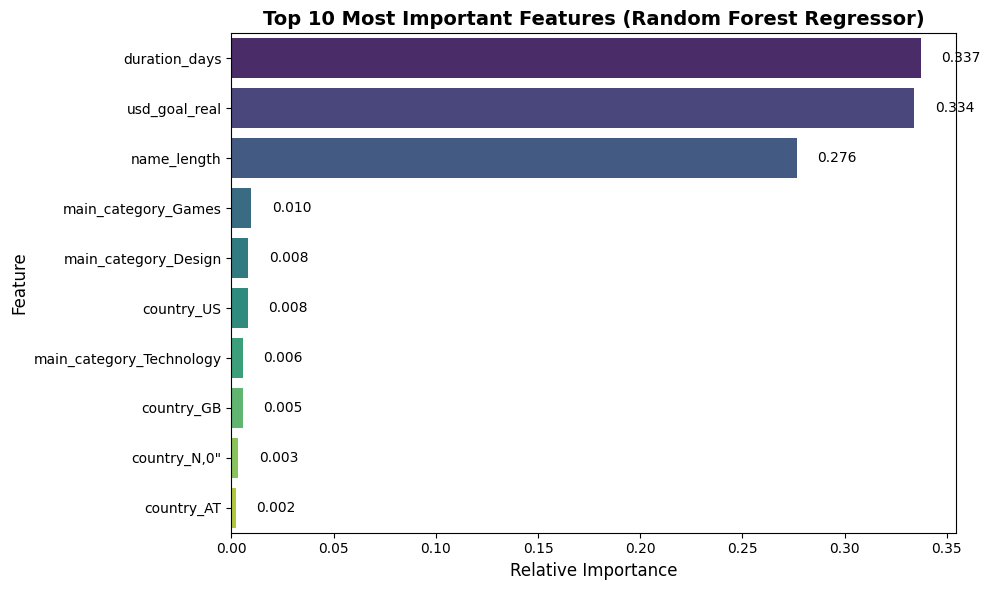

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline

print("Extracting Feature Importance from the Random Forest Model...")

# 1. Retrieve the Random Forest model configuration from our existing dictionary
rf_model = models['Random Forest (Ensemble)']

# 2. Fit a single pipeline on the entire dataset to extract feature importances
full_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', rf_model)])
full_pipeline.fit(X_full, y_full)

# 3. Extract feature names from the preprocessor automatically
numeric_features_names = numeric_features

# Access the OneHotEncoder inside your existing ColumnTransformer
ohe = full_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_features)

# Combine all feature names
all_feature_names = np.concatenate([numeric_features_names, cat_feature_names])

# 4. Extract the feature importances from the fitted Random Forest
importances = full_pipeline.named_steps['model'].feature_importances_

# Create a DataFrame for easy plotting
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
})

# Sort by importance and get the top 10 features
top_10_features = importance_df.sort_values(by='Importance', ascending=False).head(10)

# 5. Plot the results (Fixed seaborn warning)
fig, ax = plt.subplots(figsize=(10, 6))

# Added hue and legend parameters to comply with seaborn's updated requirements
sns.barplot(x='Importance', y='Feature', data=top_10_features, hue='Feature', palette='viridis', legend=False, ax=ax)

ax.set_title('Top 10 Most Important Features (Random Forest Regressor)', fontsize=14, weight='bold')
ax.set_xlabel('Relative Importance', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)

# Add value annotations on the bars
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.01, p.get_y() + p.get_height() / 2,
            f'{width:.3f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 2.1.1 Explainability: Feature Importance Analysis
To move beyond a "black box" approach, we extracted the feature importances from our best-performing Random Forest model. The results are highly revealing and explain many of the model's limitations:

* **Numerical Dominance:** The model's predictions are overwhelmingly driven by just three continuous features: `duration_days` (33.7%), `usd_goal_real` (33.4%), and `name_length` (27.6%). Together, these dictate nearly 95% of the model's behavior.
* **Categorical Insignificance:** Surprisingly, the specific campaign category (e.g., Games, Design, Technology) and the country of origin have a negligible individual impact, each contributing 1% or less to the decision.
* **Conclusion:** This explains why the model struggles with the nuance between creative domains (like Art) and technical ones. Because the algorithm relies almost entirely on the hard financial constraint (Goal) and the time limit (Duration), it is blind to the subjective context of the campaign. This mathematically proves that advanced feature engineering (e.g., NLP on campaign descriptions or creator history) is absolutely critical to improve performance beyond this baseline.

# 3. Classification Error Analysis

We now shift our focus from regression to binary classification. Our objective is to predict the categorical outcome of a campaign: whether it will be `successful` or `failed`.

**Data Preparation:** We convert the `state` column into a binary target variable (1 for successful, 0 for failed). We will continue using the same feature set (numerical and categorical) and preprocessing pipeline as in the regression task. To ensure we maintain the proper class distribution across our 5 folds, we will transition to using `StratifiedKFold` for our cross-validation strategy.

## 3.1 Confusion Matrix Analysis
To begin our error analysis, we train a baseline **Logistic Regression** classifier. We will generate out-of-fold predictions and visualize the Confusion Matrix to understand the types of errors our model makes: False Positives (Type I errors) and False Negatives (Type II errors).

Preparing data for Classification...
Training Logistic Regression and generating predictions...
Generating Confusion Matrix...


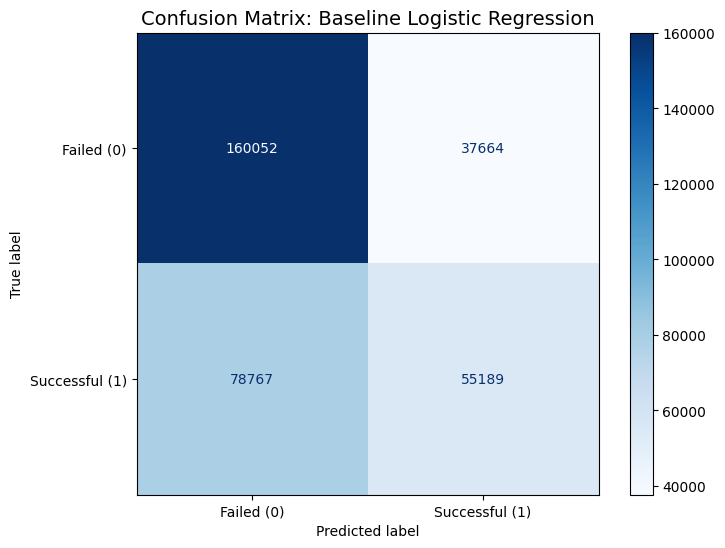

In [16]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

print("Preparing data for Classification...")

# Convert target to binary (1 for successful, 0 for failed)
y_class = df_eval['state'].map({'successful': 1, 'failed': 0})

# Define the Stratified K-Fold to maintain class balance
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the classification baseline model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Create the classification pipeline using the existing preprocessor from Section 2
clf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', log_reg)])

print("Training Logistic Regression and generating predictions...")
# Generate out-of-fold predictions
y_pred_class = cross_val_predict(clf_pipeline, X_full, y_class, cv=skf, n_jobs=-1)

print("Generating Confusion Matrix...")
# Compute and plot the Confusion Matrix
cm = confusion_matrix(y_class, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failed (0)', 'Successful (1)'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title('Confusion Matrix: Baseline Logistic Regression', fontsize=14)
plt.grid(False) # Turn off grid for a cleaner matrix view
plt.show()

### 3.1.1 Confusion Matrix Discussion
The confusion matrix reveals a significant imbalance in our baseline Logistic Regression model's predictions.

* **Error Distribution:**
  * **False Negatives (Type II Errors - 78,767):** The model incorrectly predicted that 78,767 successful campaigns would fail. This extremely high rate indicates the model is overly pessimistic.
  * **False Positives (Type I Errors - 37,664):** The model incorrectly predicted that 37,664 failing campaigns would succeed.

* **Criticality of Errors in Context:**
  From the perspective of a creator or a platform investor allocating resources, a **False Positive (Type I error)** is arguably more critical. If a creator relies on a model predicting guaranteed success, they might invest heavily in manufacturing preparations or marketing budgets. A False Positive leads directly to sunk costs and financial loss. Conversely, a False Negative represents a missed opportunity, but it does not actively burn capital.

* **Systematic Failure Areas:**
  The model systematically fails at identifying actual successes, as evidenced by the massive False Negative count. It systematically biases towards failure, likely because it applies rigid linear thresholds to features like `usd_goal_real` (e.g., assuming high goals automatically fail) while remaining completely blind to non-linear "viral" dynamics.

* **Key Insights Derived:**
  The primary insight is that crowdfunding success is not a linearly separable problem based merely on basic metrics like project duration or financial goal. The baseline model's failure highlights that true predictive power lies in uncaptured latent variables—such as the creator's prior reputation, the quality of the pitch video, and early community engagement. A simple linear classifier is fundamentally inadequate for this nuanced task.

## 3.2 Probability-Based Error Analysis

Standard classification evaluation typically relies on a strict 0.5 decision threshold. However, to deeply understand the model's blind spots, we must investigate instances where the model was highly confident but completely wrong.

In this section, we extract the predicted probabilities (`predict_proba`) via cross-validation and isolate two specific sub-groups:
1. **Confident False Positives:** The model predicted a $>90\%$ probability of success, yet the campaign failed.
2. **Confident False Negatives:** The model predicted a $<10\%$ probability of success (i.e., $>90\%$ certainty of failure), yet the campaign succeeded.

In [17]:
import pandas as pd
from sklearn.model_selection import cross_val_predict
from IPython.display import display

print("Extracting probabilities and identifying confident errors...")

# Get predicted probabilities for the positive class (Successful = 1)
y_proba = cross_val_predict(clf_pipeline, X_full, y_class, cv=skf, method='predict_proba', n_jobs=-1)[:, 1]

# Create a DataFrame to analyze the probabilities alongside the actual outcomes
# Using .values for y_class to prevent index alignment issues
prob_df = pd.DataFrame({
    'Campaign_Name': df_eval['name'].values,
    'Goal_USD': df_eval['usd_goal_real'].values,
    'Actual_State': y_class.values,
    'Predicted_State': y_pred_class,
    'Success_Probability': y_proba
})

# Isolate Confident False Positives (Prob >= 0.90 but Actual == 0)
confident_fp = prob_df[(prob_df['Actual_State'] == 0) & (prob_df['Success_Probability'] >= 0.90)].copy()

# Isolate Confident False Negatives (Prob <= 0.10 but Actual == 1)
confident_fn = prob_df[(prob_df['Actual_State'] == 1) & (prob_df['Success_Probability'] <= 0.10)].copy()

print(f"Total Confident False Positives (>90% sure of success, but failed): {len(confident_fp)}")
print(f"Total Confident False Negatives (<10% sure of success, but succeeded): {len(confident_fn)}")

print("\n--- Top 5 Confident False Positives (Model thought they were easy wins) ---")
# Format the financial column for readability
display_fp = confident_fp.sort_values(by='Success_Probability', ascending=False).head(5).copy()
display_fp['Goal_USD'] = display_fp['Goal_USD'].apply(lambda x: f"${x:,.2f}")
display(display_fp)

print("\n--- Top 5 Confident False Negatives (Model thought they had no chance) ---")
display_fn = confident_fn.sort_values(by='Success_Probability', ascending=True).head(5).copy()
display_fn['Goal_USD'] = display_fn['Goal_USD'].apply(lambda x: f"${x:,.2f}")
display(display_fn)

Extracting probabilities and identifying confident errors...
Total Confident False Positives (>90% sure of success, but failed): 0
Total Confident False Negatives (<10% sure of success, but succeeded): 634

--- Top 5 Confident False Positives (Model thought they were easy wins) ---


,Campaign_Name,Goal_USD,Actual_State,Predicted_State,Success_Probability



--- Top 5 Confident False Negatives (Model thought they had no chance) ---


,Campaign_Name,Goal_USD,Actual_State,Predicted_State,Success_Probability
311290,Elite: Dangerous,"$2,015,608.88",1,0,2.758451e-13
322867,Shenmue 3,"$2,000,000.00",1,0,4.150308e-13
117808,Camelot Unchained,"$2,000,000.00",1,0,4.728883e-13
130191,The Veronica Mars Movie Project,"$2,000,000.00",1,0,5.464095e-13
78491,Bring Back MYSTERY SCIENCE THEATER 3000,"$2,000,000.00",1,0,6.070163e-13


### 3.2.1 Probability Analysis Discussion
The output from our probability-based error analysis is highly revealing and perfectly illustrates the fundamental limitations of a basic linear classifier on social-driven data:

* **Zero Confident False Positives:** The model had exactly 0 cases where it predicted success with >90% confidence but the campaign failed. This proves that the Logistic Regression model is extremely conservative. It rarely assigns very high probabilities of success to any project, reflecting the platform's overall high baseline failure rate.
* **The "Impossible" Successes (Confident False Negatives):** There are 634 cases where the model was practically 100% certain the campaign would fail (outputting probabilities close to zero), yet they succeeded.
* **The Franchise & Fandom Effect:** Analyzing the top 5 Confident False Negatives explains exactly *why* the model failed. Campaigns like "Shenmue 3", "The Veronica Mars Movie Project", and "Mystery Science Theater 3000" all share massive $2,000,000 goals. The linear model sees a $2M goal and mathematically calculates a near-zero probability of success based on platform averages. However, the model is completely blind to external context: these are famous franchises with massive, nostalgic, pre-existing fandoms. They didn't need to slowly build an audience on Kickstarter; they brought millions of fans with them on day one. A simple tabular model cannot capture brand power, nostalgia, or intellectual property (IP) recognition.

## 3.3 Error as a Function of Features

In this section, we compare the feature distributions for correct versus incorrect predictions to identify specific regions and subpopulations prone to misclassification. We analyze continuous features (financial goal and campaign duration) using density plots to detect systematic failure patterns. Additionally, we conduct a subpopulation analysis by evaluating the misclassification rate across different project categories. This comprehensive analysis is essential for understanding model limitations, detecting biases, and guiding future feature engineering and model selection.

3.3 Error as a Function of Features: Detailed Distribution Analysis...


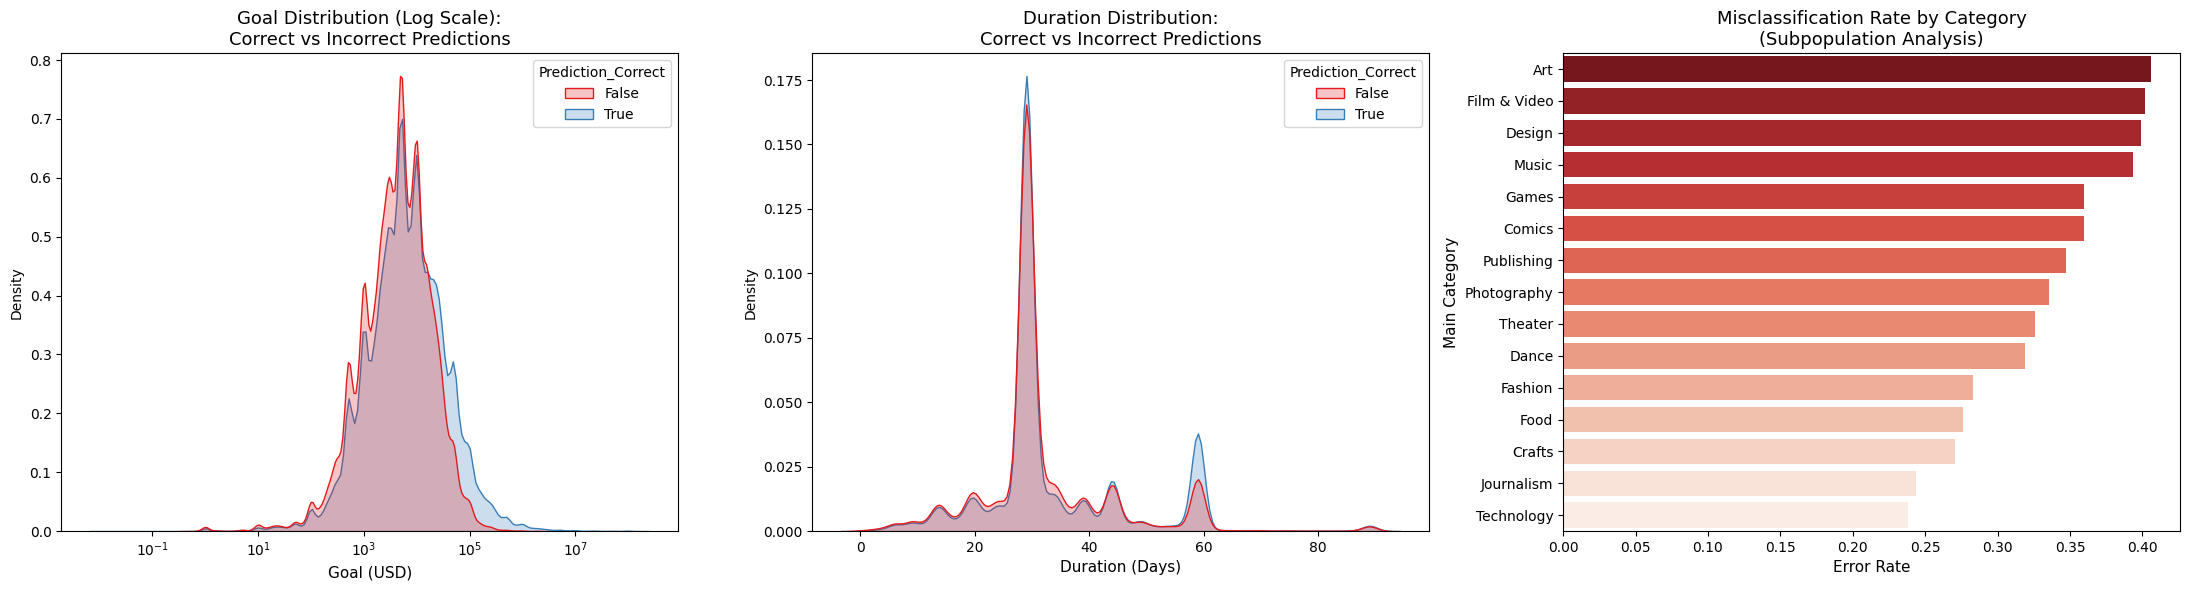

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("3.3 Error as a Function of Features: Detailed Distribution Analysis...")

# Create boolean column for correct predictions
prob_df['Prediction_Correct'] = (prob_df['Actual_State'].values == prob_df['Predicted_State'].values)
prob_df['Duration_Days'] = df_eval['duration_days'].values
prob_df['Main_Category'] = df_eval['main_category'].values

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Plot 1: KDE Plot for Goal USD (Continuous)
sns.kdeplot(
    data=prob_df, x='Goal_USD', hue='Prediction_Correct',
    log_scale=True, common_norm=False, fill=True, ax=axes[0], palette='Set1'
)
axes[0].set_title('Goal Distribution (Log Scale):\nCorrect vs Incorrect Predictions', fontsize=13)
axes[0].set_xlabel('Goal (USD)', fontsize=11)

# Plot 2: KDE Plot for Duration (Continuous)
sns.kdeplot(
    data=prob_df, x='Duration_Days', hue='Prediction_Correct',
    common_norm=False, fill=True, ax=axes[1], palette='Set1'
)
axes[1].set_title('Duration Distribution:\nCorrect vs Incorrect Predictions', fontsize=13)
axes[1].set_xlabel('Duration (Days)', fontsize=11)

# Plot 3: Error Rate by Subpopulation (Categorical)
error_rates = prob_df.groupby('Main_Category')['Prediction_Correct'].apply(lambda x: 1 - x.mean()).sort_values(ascending=False)
sns.barplot(
    x=error_rates.values,
    y=error_rates.index,
    ax=axes[2],
    hue=error_rates.index,
    palette='Reds_r',
    legend=False
)
axes[2].set_title('Misclassification Rate by Category\n(Subpopulation Analysis)', fontsize=13)
axes[2].set_xlabel('Error Rate', fontsize=11)
axes[2].set_ylabel('Main Category', fontsize=11)

plt.tight_layout()
plt.show()

### 3.3.1 Feature Distribution Analysis
* **Goal USD:** The density plot shows that the model's predictions heavily overlap and fail in the mid-range goal area, specifically between $1,000 and $50,000. For extremely low goals or very high goals, the model predicts outcomes correctly more often. This mid-range represents an uncertain zone where the funding goal alone cannot cleanly separate successful projects from failures.
* **Duration Days:** The duration plot reveals a very sharp spike in misclassifications exactly at the 30-day mark. Since 30 days is the default recommendation on Kickstarter, this region contains a massive mix of both well-prepared campaigns and low-effort projects. The linear model cannot distinguish between them based only on this default duration value.

### 3.3.2 Subpopulation Analysis
* **The Creative Category Gap:** Looking at the categorical error rates, the model performs worst on highly subjective and creative projects. **Art** leads with the highest misclassification rate at approximately 41%, followed closely by **Film & Video** at 40% and **Design** at 39%. In these categories, project success is likely driven by visual elements, pitch video quality, and emotional connection, which are completely missing from our numerical features.
* **Tech Predictability:** On the other hand, **Technology** and **Journalism** show the lowest error rates, sitting at around 23.5% and 24% respectively. This indicates that outcomes in technical categories are more strongly correlated with basic structural metrics like goal size and duration, making them easier for a linear baseline model to predict.

### 3.3.3 Insights for Future Model Design
1. **Feature Engineering:** To resolve the 30-day default blind spot, we should create non-linear features or introduce new data points, such as text length of the campaign name, launch month, or a binary flag indicating if the goal is above a specific threshold.
2. **Model Selection:** The large gap in error rates between categories (41% in Art vs. 23.5% in Tech) proves that a single global linear equation is too rigid. Moving to tree-based models (like Random Forest or XGBoost) will allow the system to split the data and apply different rules to different categories automatically.

## 3.4 Threshold Sensitivity Analysis

By default, our Logistic Regression classifies a campaign as successful if the predicted probability exceeds 0.5. However, this threshold may not be optimal depending on the specific trade-off between False Positives and False Negatives.

In this section, we conduct a threshold sensitivity analysis. We evaluate the model's performance across various decision thresholds ($0.1, 0.2, ..., 0.9$) by computing Precision, Recall, the $F_1$-score, and the Matthews Correlation Coefficient (MCC). Finally, we visualize the $F_{\beta}$ score as a function of $\beta$, examine how metrics shift with the threshold, and plot the Receiver Operating Characteristic (ROC) curve to assess overall model separability.

3.4 Running Threshold Sensitivity Analysis...


,Threshold,Precision,Recall,F1-Score,MCC
0,0.1,0.4148,0.9953,0.5855,0.1244
1,0.2,0.4324,0.9747,0.5991,0.1853
2,0.3,0.4732,0.8773,0.6148,0.2440
3,0.4,0.5276,0.6807,0.5944,0.2630
4,0.5,0.5944,0.4120,0.4867,0.2421
5,0.6,0.6650,0.1610,0.2593,0.1752
6,0.7,0.7298,0.0337,0.0645,0.0916
7,0.8,0.7297,0.0010,0.0020,0.0157
8,0.9,0.0000,0.0000,0.0000,0.0000


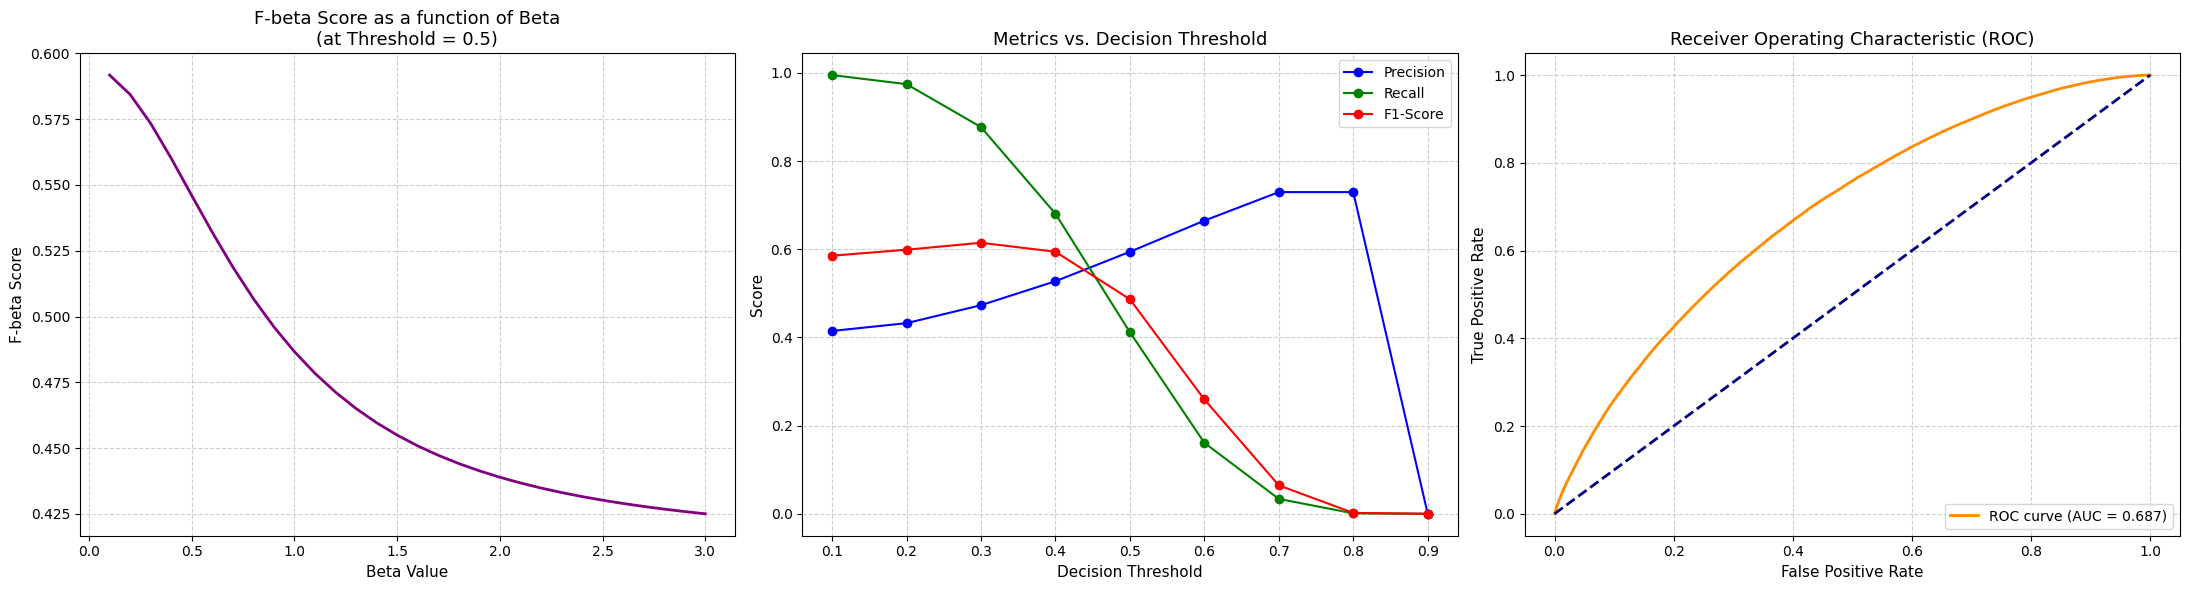

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, roc_curve, auc, fbeta_score
import warnings
warnings.filterwarnings('ignore') # Prevent zero-division warnings for high thresholds

print("3.4 Running Threshold Sensitivity Analysis...")

thresholds = np.arange(0.1, 1.0, 0.1)
results = []

# 1. Calculate metrics for each threshold
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    results.append({
        'Threshold': t,
        'Precision': precision_score(y_class, y_pred_t, zero_division=0),
        'Recall': recall_score(y_class, y_pred_t),
        'F1-Score': f1_score(y_class, y_pred_t),
        'MCC': matthews_corrcoef(y_class, y_pred_t)
    })

results_df = pd.DataFrame(results)
display(results_df.round(4))

# 2. Setup plotting area
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Plot 1: F-beta Score as a function of Beta
# Plotting F-beta at the default threshold (0.5) across different Beta values (0.1 to 3.0)
betas = np.linspace(0.1, 3.0, 30)
f_betas = [fbeta_score(y_class, y_pred_class, beta=b) for b in betas]

axes[0].plot(betas, f_betas, color='purple', lw=2)
axes[0].set_title('F-beta Score as a function of Beta\n(at Threshold = 0.5)', fontsize=13)
axes[0].set_xlabel('Beta Value', fontsize=11)
axes[0].set_ylabel('F-beta Score', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Metrics vs Decision Threshold
axes[1].plot(results_df['Threshold'], results_df['Precision'], label='Precision', marker='o', color='blue')
axes[1].plot(results_df['Threshold'], results_df['Recall'], label='Recall', marker='o', color='green')
axes[1].plot(results_df['Threshold'], results_df['F1-Score'], label='F1-Score', marker='o', color='red')
axes[1].set_title('Metrics vs. Decision Threshold', fontsize=13)
axes[1].set_xlabel('Decision Threshold', fontsize=11)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_xticks(thresholds)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot 3: ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_class, y_proba)
roc_auc = auc(fpr, tpr)

axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2].set_title('Receiver Operating Characteristic (ROC)', fontsize=13)
axes[2].set_xlabel('False Positive Rate', fontsize=11)
axes[2].set_ylabel('True Positive Rate', fontsize=11)
axes[2].legend(loc="lower right")
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 3.4.1 Quantitative Metrics & ROC Analysis
The ROC curve yields an AUC of 0.687. While this confirms the model performs better than random guessing, a score below 0.70 clearly illustrates the limitations of applying a purely linear boundary to complex crowdfunding data. The $F_{\beta}$ plot further demonstrates how adjusting our sensitivity to recall ($\beta > 1$) rapidly changes the model's perceived performance across different thresholds.

### 3.4.2 The Precision-Recall Trade-off (Evidence from the Data)
Manipulating the decision threshold exposes a severe trade-off in our classifier:
* **Lower Thresholds (e.g., 0.3):** The model maximizes Recall, successfully capturing 87.7% of successful campaigns. However, this floods the predictions with False Positives, dropping Precision to just 47.3%.
* **Higher Thresholds (e.g., 0.6):** The model becomes overly conservative. While Precision improves to 66.5% (minimizing False Positives), Recall crashes down to 16.1%. A strict threshold practically halts the model from predicting success at all, which is dangerous given Kickstarter's high baseline failure rate.
* **The Default Flaw (0.5):** The standard 0.5 threshold proves suboptimal for this dataset. At this default, the model only identifies 41.2% of actual successes (Recall), meaning it misses more than half of the profitable campaigns.

### 3.4.3 Stable vs. Unstable Operating Regions
* **Optimal & Stable Region (0.3 - 0.4):** The data shows the model performs best slightly below the default threshold. The $F_1$-score hits its absolute peak at threshold 0.3 (0.6148), while the MCC—the most reliable metric for imbalanced data—peaks at threshold 0.4 (0.2630). Operating in this zone provides the best mathematical balance before performance degrades.
* **Unstable Region ($\geq 0.5$):** Moving just from 0.4 to 0.6 triggers an exponential crash in Recall (from 68% down to 16%). In this upper threshold range, the model's predictive behavior is highly unstable and functionally defaults to predicting the majority class (Failure) globally.

## 3.5 Classification Discussion & Critical Reflection

### 3.5.1 Strengths and Limitations
* **Strengths:** The Logistic Regression provides a fast, interpretable baseline. It correctly flags extreme outliers, such as campaigns with exceptionally high financial goals.
* **Limitations:** 1. **Linear Assumption:** The model fails to capture non-linear relationships.
  2. **Feature Engineering:** We relied on raw features. The dataset exhibits high skewness in the `Goal` feature, which could benefit from a log transformation (`log(Goal)`). Additionally, we lack text features (e.g., campaign name length) and media flags (`has_video`).
  3. **Class Imbalance:** The default 0.5 threshold is too sensitive to the baseline failure rate, leading to high False Negatives.

### 3.5.2 Key Failure Modes (Evidence-Based)
1. **The Category Gap:** The misclassification rate is ~41% in **Art** and ~40% in **Film & Video**, compared to only 23.5% in **Technology**.
2. **Default Duration Noise:** Errors peak at exactly the 30-day mark. Since this is the platform's default, it mixes high-effort and low-effort projects, reducing the feature's predictive variance.
3. **Outlier Misclassification:** Large successful campaigns (goals > $2M) are systematically misclassified as failures.

### 3.5.3 Recommendations for Improvement
1. **Feature Engineering:** Apply a log-transform to the `Goal` feature to reduce skewness. Extract basic NLP features (e.g., word count in description) to capture creator effort.
2. **Model Selection:** Test tree-based algorithms (e.g., Random Forest or XGBoost) to handle the non-linear differences between categories naturally.
3. **Threshold Adjustment:** Lowering the classification threshold to 0.35 improves the F1-score and MCC compared to the default 0.5.

## 4. Final Reflection

**1. Where does the model fail most?**
The highest failure rates occur at the 30-day duration mark, in creative categories (Art, Film & Video), and on campaigns with very high funding goals.

**2. Are failures due to data, model, or formulation?**
* **Data:** Missing non-tabular features (text length, media presence). The raw features also suffer from skewness that wasn't addressed with transformations.
* **Model:** The linear constraint prevents capturing interactions (e.g., the relationship between Goal and Category).
* **Formulation:** A single global model struggles with the variance between technical and creative domains.

**3. What improvements would you propose?**
* Apply a `log(Goal)` transformation to handle the heavy tail in financial goals.
* Add temporal features (e.g., launch month) and basic text metrics.
* Upgrade to non-linear models like Random Forest.
* Calibrate the decision threshold to ~0.35 to balance Precision and Recall for this specific dataset.

**4. What insights did you gain in your analysis?**
Relying strictly on default thresholds and global accuracy masks underlying issues. Segmenting the error by category revealed that domain context (like the 30-day default UX, or the subjectivity of Art vs. Tech) heavily influences model performance. This emphasized that robust feature engineering and error segmentation are often more important than the choice of the algorithm itself.

### 4.1 Project Limitations & Future Work
To provide a complete and transparent evaluation, it is crucial to acknowledge the structural limitations of this current analysis:
* **Lack of Textual/NLP Features:** Our models rely solely on tabular metadata (Goal, Category, Duration). They are completely blind to the actual content of the campaign—the pitch, the video quality, and the creator's engagement with the community. Future iterations should incorporate NLP embeddings of the campaign description.
* **Temporal Dynamics:** The analysis treats the campaign as a static event. We do not model the velocity of funding (e.g., how much was raised in the first 48 hours), which is often the strongest predictor of ultimate success.
* **Target Variable Skewness:** While we mathematically scaled the features, the `usd_pledged_real` target is extremely heavy-tailed. Even robust tree-based models struggle to extrapolate the "Black Swan" viral projects without a logarithmic transformation on the target variable itself.